# BRFSS 2024 Colorectal Cancer Screening: Descriptive Analysis (EDA)

**Project:** Predicting colorectal cancer screening non-compliance to guide targeted outreach
**Input:** `crc_analytic_dataset.csv` (Data Preparation output — 227,647 eligible respondents)

This notebook satisfies **Section 6.3 (Descriptive analysis)** of the project brief. Every number
is checked against the figures already stated in the **Week 2 Proposal (Annex C)**, and also
addresses the professor's proposal feedback on outcome recoding and outreach differentiation.

## Chart selection for the final report

| # | Item | Why it's included |
|---|---|---|
| 1 | Outcome recoding table | Addresses professor's request for a clear `_CRCREC3` mapping |
| 2 | Cohort flow | Required explicitly — shows 457,670 → 227,647 |
| 3 | Outcome distribution (3-category) | Required explicitly — the headline numbers |
| 4 | Never-screened vs overdue comparison | Addresses professor's question on outreach differentiation |
| 5 | Table 1 | Required explicitly — predictor summary |
| 6 | Non-compliance by income | Strongest socioeconomic signal |
| 7 | Non-compliance by insurance / personal doctor | Strongest access signal — the paper's central finding |

Additional exploratory charts (age, race, general health) are included at the end as backup —
useful for Q&A, but not needed in the main report given the 2,500-3,500 word limit.


In [20]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)

DATA_DIR = Path("../data")
PROCESSED_DIR = DATA_DIR / "processed"
DATA_PATH = PROCESSED_DIR / "crc_analytic_dataset.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"{DATA_PATH} not found. Run '1 Data Preparation.ipynb' first to "
        "generate the analytic dataset, or update DATA_DIR above to point "
        "at the folder containing data/processed/."
    )

df = pd.read_csv(DATA_PATH)
print("Loaded:", DATA_PATH)
print("Shape:", df.shape)
df.head()

Loaded: ..\data\processed\crc_analytic_dataset.csv
Shape: (227647, 27)


,respondent_id,source_row_id,state_fips,validation_group_state,age_exact,_CRCREC3,crc_noncompliant,crc_screening_status,noncompliance_type,age_group,sex,race_ethnicity,education_level,income_group,employment_status,marital_status,urban_rural,insurance_status,personal_doctor,cost_barrier,checkup_recency,general_health,diabetes_status,heart_disease,smoking_status,bmi_category,housing_tenure
0,01-2024000003,3,1,1,59,3,1,Never screened,Never screened,55-59,Male,"White only, non-Hispanic",Attended college or technical school,Not reported,Employed for wages,Member of an unmarried couple,Urban,Insured,No personal doctor,Yes,5 or more years,Very good,No diabetes,CHD or MI not reported,Current smoker - every day,Normal weight,Own
1,01-2024000005,5,1,1,47,3,1,Never screened,Never screened,45-49,Male,"White only, non-Hispanic",Attended college or technical school,"$15,000 to < $25,000",Unable to work,Never married,Urban,Insured,Has personal doctor,No,Within past year,Good,No diabetes,CHD or MI not reported,Never smoked,Normal weight,Own
2,01-2024000006,6,1,1,54,1,0,Up to date,Not applicable - compliant,50-54,Male,"White only, non-Hispanic",Graduated high school,"$100,000 to < $200,000",Employed for wages,Married,Urban,Insured,Has personal doctor,No,Within past year,Good,Diabetes,CHD or MI not reported,Never smoked,Obese,Rent
3,01-2024000007,7,1,1,71,1,0,Up to date,Not applicable - compliant,70-74,Female,"White only, non-Hispanic",Attended college or technical school,"$35,000 to < $50,000",Retired,Married,Rural,Insured,Has personal doctor,No,Within past year,Fair,No diabetes,CHD or MI reported,Never smoked,Obese,Own
4,01-2024000008,8,1,1,68,1,0,Up to date,Not applicable - compliant,65-69,Female,"White only, non-Hispanic",Attended college or technical school,Not reported,Retired,Married,Rural,Insured,Has personal doctor,No,Within past year,Poor,Diabetes,CHD or MI not reported,Never smoked,Obese,Own


## 1. Outcome recoding table for `_CRCREC3`

Before summarising the outcome, it's worth being explicit about how the raw BRFSS variable maps
to the labels used throughout this notebook (the professor asked for this to be shown clearly):

| `_CRCREC3` value | Meaning | Recoded label | Compliance status |
|---|---|---|---|
| 1 | Had at least one recommended CRC test within the recommended interval | Up to date | Compliant |
| 2 | Did not have any recommended CRC test within the recommended interval | Overdue | Non-compliant |
| 3 | Have never had any recommended CRC test | Never screened | Non-compliant |
| Blank | Outside age 45-75, or otherwise not eligible | Excluded from analytic sample | N/A |

`crc_noncompliant` = 0 if `_CRCREC3` = 1, else 1 (collapsing categories 2 and 3 for the main
binary modelling outcome). `crc_screening_status` keeps all three categories separately, which
is used below to check whether that collapsing is actually reasonable.


## 2. Cohort flow

**Proposal source (Annex B frequency table):** total BRFSS 2024 respondents = 457,670;
not eligible (outside age 45-75, or blank outcome) = 230,023; eligible analytic sample = 227,647.


Total BRFSS 2024 respondents: 457,670
Not eligible (age outside 45-75 or blank outcome): 230,023
Eligible analytic sample: 227,647  (49.7% of total)


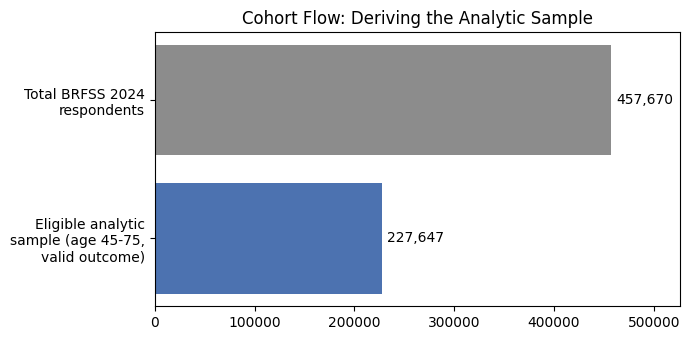

In [21]:
total_brfss = 457_670
eligible = len(df)
not_eligible = total_brfss - eligible

print(f"Total BRFSS 2024 respondents: {total_brfss:,}")
print(f"Not eligible (age outside 45-75 or blank outcome): {not_eligible:,}")
print(f"Eligible analytic sample: {eligible:,}  ({eligible/total_brfss*100:.1f}% of total)")

fig, ax = plt.subplots(figsize=(7,3.5))
stages = ["Total BRFSS 2024\nrespondents", "Eligible analytic\nsample (age 45-75,\nvalid outcome)"]
values = [total_brfss, eligible]
bars = ax.barh(stages, values, color=["#8C8C8C", "#4C72B0"])
for bar, v in zip(bars, values):
    ax.text(v + 5000, bar.get_y() + bar.get_height()/2, f"{v:,}", va="center", fontsize=10)
ax.set_xlim(0, total_brfss * 1.15)
ax.set_title("Cohort Flow: Deriving the Analytic Sample")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../figures/fig0_cohort_flow.png", dpi=150)
plt.show()


**What this shows:** out of the full 2024 BRFSS survey (457,670 respondents across the US), only about half (227,647, or ~49.8%) fall inside the study's age window (45–75) *and* have a usable screening record. The other half were excluded — mainly because they're younger than 45 or older than 75, which is outside the range USPSTF screening guidelines apply to.

## 3. Outcome distribution

**Proposal claim (Annex C):** eligible sample = 227,647; non-compliance = 26.5%; majority-class accuracy floor = 0.735.


In [22]:
n_total = len(df)
noncompliance_rate = df["crc_noncompliant"].mean()
majority_floor = max(noncompliance_rate, 1 - noncompliance_rate)

print("Eligible respondents:", f"{n_total:,}", "  (proposal: 227,647)")
print("Non-compliance rate:", f"{noncompliance_rate*100:.1f}%", " (proposal: 26.5%)")
print("Majority-class accuracy floor:", round(majority_floor, 3), " (proposal: 0.735)")
print()
print(df["crc_screening_status"].value_counts())


Eligible respondents: 227,647   (proposal: 227,647)
Non-compliance rate: 26.5%  (proposal: 26.5%)
Majority-class accuracy floor: 0.735  (proposal: 0.735)

crc_screening_status
Up to date        167374
Never screened     43930
Overdue            16343
Name: count, dtype: int64


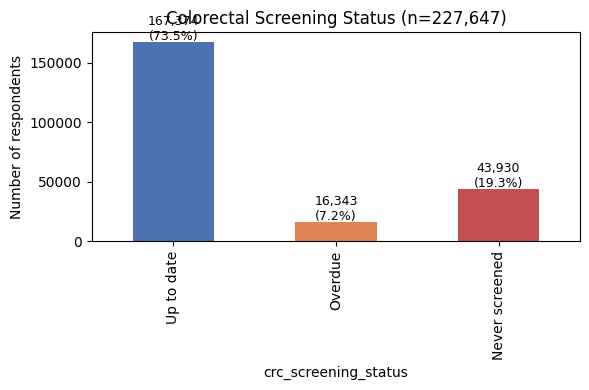

In [23]:
fig, ax = plt.subplots(figsize=(6,4))
counts = df["crc_screening_status"].value_counts().reindex(["Up to date","Overdue","Never screened"])
counts.plot(kind="bar", ax=ax, color=["#4C72B0","#DD8452","#C44E52"])
ax.set_title(f"Colorectal Screening Status (n={n_total:,})")
ax.set_ylabel("Number of respondents")
for i, v in enumerate(counts):
    ax.text(i, v + 2000, f"{v:,}\n({v/n_total*100:.1f}%)", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("../figures/fig1_outcome_distribution.png", dpi=150)
plt.show()


**What this shows:** about 3 in 4 eligible respondents (73.5%) are up to date with screening. Of the remaining 26.5% who are non-compliant, most (19.3%) have *never* been screened at all, and a smaller group (7.2%) were screened before but have since fallen overdue.

**Result: matches the proposal exactly** — 227,647 eligible, 26.5% non-compliant.

This 19.3% vs 7.2% split raises a natural question: does it actually make sense to collapse these two groups into one "non-compliant" outcome, or do they represent different problems? The next section checks this directly.

## 4. Are "never screened" and "overdue" different outreach problems?

The binary `crc_noncompliant` outcome used later in this notebook treats "overdue" and "never
screened" as the same thing. Here we check whether that's a reasonable simplification by
comparing how each of the three outcome categories varies across insurance status and age —
the two strongest predictors identified in this dataset.


In [24]:
ins_tab = pd.crosstab(df["insurance_status"], df["crc_screening_status"], normalize="index")[["Up to date","Overdue","Never screened"]] * 100
ins_tab = ins_tab.reindex(["Insured","Not reported","Uninsured"])
ins_tab.round(1)


crc_screening_status,Up to date,Overdue,Never screened
insurance_status,,,
Insured,75.5,7.2,17.3
Not reported,64.3,7.2,28.5
Uninsured,30.0,7.8,62.2


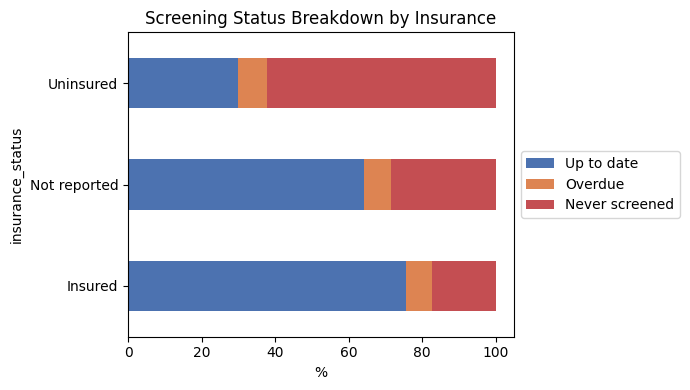

In [25]:
fig, ax = plt.subplots(figsize=(7,4))
ins_tab.plot(kind="barh", stacked=True, ax=ax, color=["#4C72B0","#DD8452","#C44E52"])
ax.set_xlabel("%")
ax.set_title("Screening Status Breakdown by Insurance")
ax.legend(loc="center left", bbox_to_anchor=(1,0.5))
plt.tight_layout()
plt.savefig("../figures/fig8_status_by_insurance.png", dpi=150)
plt.show()


In [26]:
age_order = ["45-49","50-54","55-59","60-64","65-69","70-74","75 (source category 75-79)","Not reported"]
age_tab = pd.crosstab(df["age_group"], df["crc_screening_status"], normalize="index")[["Up to date","Overdue","Never screened"]].reindex(age_order) * 100
age_tab.round(1)


crc_screening_status,Up to date,Overdue,Never screened
age_group,,,
45-49,44.1,5.0,50.9
50-54,62.6,6.2,31.2
55-59,74.9,6.5,18.7
60-64,78.1,8.7,13.2
65-69,82.6,7.7,9.8
70-74,84.7,7.5,7.8
75 (source category 75-79),84.3,8.7,7.0
Not reported,59.1,7.3,33.7


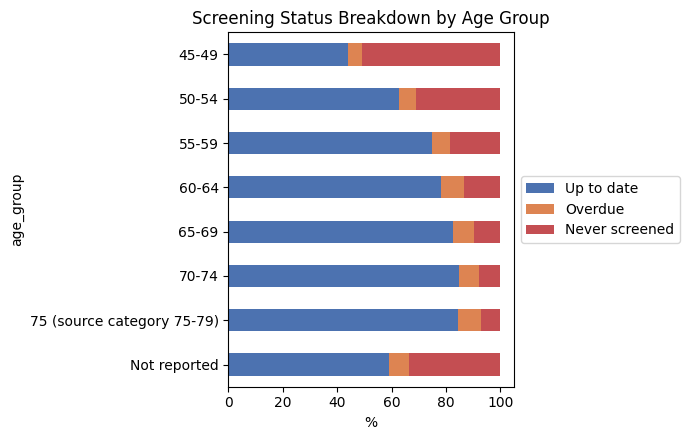

In [27]:
fig, ax = plt.subplots(figsize=(7,4.5))
age_tab.plot(kind="barh", stacked=True, ax=ax, color=["#4C72B0","#DD8452","#C44E52"])
ax.set_xlabel("%")
ax.set_title("Screening Status Breakdown by Age Group")
ax.legend(loc="center left", bbox_to_anchor=(1,0.5))
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../figures/fig9_status_by_age.png", dpi=150)
plt.show()


**Key finding — the "overdue" rate barely moves, but "never screened" swings enormously:**

| Predictor | "Overdue" range | "Never screened" range |
|---|---|---|
| Insurance | 7.2% (insured) to 7.8% (uninsured) — almost flat | 17.3% (insured) to 62.2% (uninsured) — huge gap |
| Age | 5.0% (45-49) to 8.7% (75-79) — narrow | 50.9% (45-49) down to 7.0% (75-79) — huge gradient |

This shows these are **different outreach problems**:

- **"Overdue" looks close to a uniform baseline rate** (~5-9%) regardless of insurance or age —
  suggesting a general reminder/follow-up gap that affects everyone similarly, addressable with
  a simple recall system.
- **"Never screened" is where the access and demographic gaps concentrate** — uninsured
  respondents are over 3.5x as likely to have never screened compared to insured respondents,
  and the youngest eligible group (45-49) is over 7x as likely as the oldest. This looks driven by
  structural barriers (cost, access, awareness of eligibility) rather than simple forgetfulness.

**Operational implication for "targeted outreach":** rather than one generic flag, the model
could support two tracks — a low-cost reminder nudge for the "overdue" group, and a more
resource-intensive first-contact/education-and-access intervention for the "never screened"
group, since the two groups appear to respond to different underlying causes.

## 5. Table 1 — Predictor distribution by outcome

In [28]:
predictors_demo = ["age_group","sex","race_ethnicity","education_level","income_group",
                   "employment_status","marital_status","urban_rural"]
predictors_access = ["insurance_status","personal_doctor","cost_barrier","checkup_recency"]
predictors_health = ["general_health","diabetes_status","heart_disease","smoking_status","bmi_category"]
all_predictors = predictors_demo + predictors_access + predictors_health

table1_rows = []
for col in all_predictors:
    tab = pd.crosstab(df[col], df["crc_noncompliant"], normalize="index") * 100
    tab = tab.rename(columns={0: "Compliant %", 1: "Non-compliant %"})
    tab["N"] = df[col].value_counts()
    tab["Variable"] = col
    tab = tab.reset_index().rename(columns={col: "Category"})
    table1_rows.append(tab[["Variable","Category","N","Compliant %","Non-compliant %"]])

table1 = pd.concat(table1_rows, ignore_index=True)
table1["Compliant %"] = table1["Compliant %"].round(1)
table1["Non-compliant %"] = table1["Non-compliant %"].round(1)
table1.to_csv("../figures/table1_by_outcome.csv", index=False)
table1


crc_noncompliant,Variable,Category,N,Compliant %,Non-compliant %
0,age_group,45-49,26594,44.1,55.9
1,age_group,50-54,29152,62.6,37.4
2,age_group,55-59,32326,74.9,25.1
3,age_group,60-64,40134,78.1,21.9
4,age_group,65-69,44332,82.6,17.4
...,...,...,...,...,...
82,bmi_category,Normal weight,53504,72.4,27.6
83,bmi_category,Not reported,13268,67.5,32.5
84,bmi_category,Obese,80068,74.2,25.8
85,bmi_category,Overweight,78036,74.8,25.2


**What this shows:** this is the full reference table — every category of every predictor (all 17), with how many respondents fall into it (N) and what share of that group is compliant vs non-compliant. You won't put the whole table in the report body (too long), but it's the source you'll pull specific rows from — e.g. the income and insurance rows are what the charts below visualize directly. Keep this as a full appendix table or supplementary CSV.

## 6. Non-compliance by household income

**Proposal claim (Annex C table, exact figures):**

| Income Group | Non-compliance | N |
|---|---|---|
| Under $15k | 38.9% | 11,320 |
| $15k to $25k | 33.5% | 17,221 |
| $25k to $35k | 31.0% | 19,923 |
| $35k to $50k | 28.2% | 23,510 |
| $50k to $100k | 23.3% | 58,801 |
| $100k to $200k | 23.0% | 45,753 |
| $200k or more | 20.8% | 17,118 |


In [29]:
income_order = ["Less than $15,000","$15,000 to < $25,000","$25,000 to < $35,000",
                "$35,000 to < $50,000","$50,000 to < $100,000","$100,000 to < $200,000",
                "$200,000 or more","Not reported"]

income_summary = df.groupby("income_group")["crc_noncompliant"].agg(["mean","count"]).reindex(income_order)
income_summary["Non-compliance %"] = (income_summary["mean"] * 100).round(1)
income_summary = income_summary.rename(columns={"count": "N"})[["N","Non-compliance %"]]
income_summary


,N,Non-compliance %
income_group,,
"Less than $15,000",11320,38.9
"$15,000 to < $25,000",17221,33.5
"$25,000 to < $35,000",19923,31.0
"$35,000 to < $50,000",23510,28.2
"$50,000 to < $100,000",58801,23.3
"$100,000 to < $200,000",45753,23.0
"$200,000 or more",17118,20.8
Not reported,34001,28.0


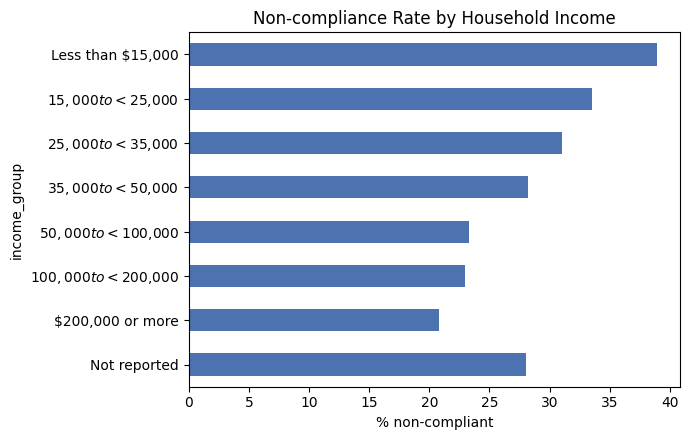

In [30]:
fig, ax = plt.subplots(figsize=(7,4.5))
income_summary["Non-compliance %"].plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("% non-compliant")
ax.set_title("Non-compliance Rate by Household Income")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("../figures/fig2_noncompliance_by_income.png", dpi=150)
plt.show()


**What this shows:** non-compliance falls steadily as income rises — from 38.9% in the lowest bracket down to 20.8% in the highest, a clean monotonic gradient with no reversals, making income a strong, reliable candidate predictor.

**Result: matches the proposal exactly** — every bracket's percentage and N reproduce Annex C to the decimal point.

## 7. Non-compliance by healthcare access

**Proposal claim:** *"Non-compliance is also far higher among the uninsured (70.0 percent versus 24.5 percent insured) and among those without a personal doctor (66.2 percent versus 25.3 percent)."*

This is the most important chart in the whole EDA — it's the empirical basis for your project's central claim (access matters more than demographics).


In [31]:
ins_summary = df.groupby("insurance_status")["crc_noncompliant"].agg(["mean","count"]).sort_values("mean", ascending=False)
ins_summary["Non-compliance %"] = (ins_summary["mean"] * 100).round(1)

doc_summary = df.groupby("personal_doctor")["crc_noncompliant"].agg(["mean","count"]).sort_values("mean", ascending=False)
doc_summary["Non-compliance %"] = (doc_summary["mean"] * 100).round(1)

print("Insurance status:\n", ins_summary[["count","Non-compliance %"]])
print()
print("Personal doctor status:\n", doc_summary[["count","Non-compliance %"]])


Insurance status:
                    count  Non-compliance %
insurance_status                          
Uninsured           8410              70.0
Not reported        6329              35.7
Insured           212908              24.5

Personal doctor status:
                       count  Non-compliance %
personal_doctor                              
No personal doctor    16751              66.2
Not reported           1581              41.7
Has personal doctor  209315              23.2


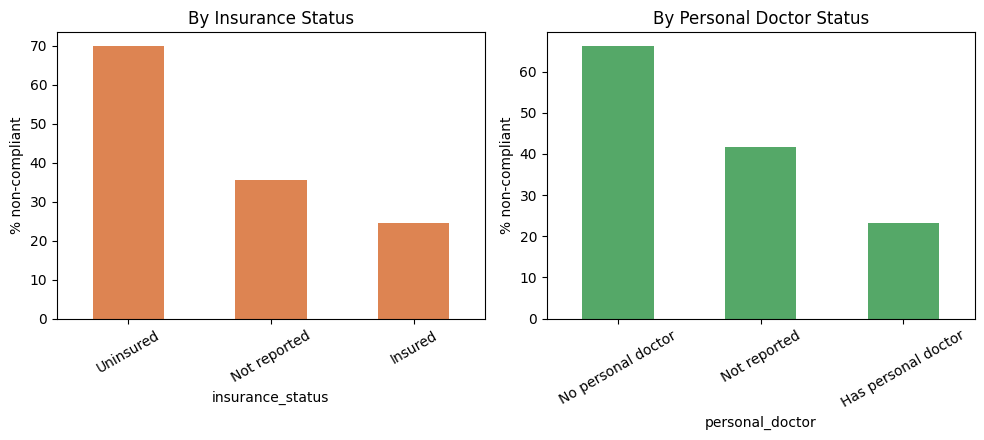

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(10,4.5))

ins_summary["Non-compliance %"].plot(kind="bar", ax=axes[0], color="#DD8452")
axes[0].set_title("By Insurance Status")
axes[0].set_ylabel("% non-compliant")
axes[0].tick_params(axis="x", rotation=30)

doc_summary["Non-compliance %"].plot(kind="bar", ax=axes[1], color="#55A868")
axes[1].set_title("By Personal Doctor Status")
axes[1].set_ylabel("% non-compliant")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../figures/fig3_noncompliance_by_access.png", dpi=150)
plt.show()


**What this shows:** this gap is much bigger than the income gap — uninsured respondents are non-compliant almost 3x as often as insured ones (70.0% vs 24.5%), and the pattern is nearly identical for having a personal doctor. Compare to income above (an 18-point spread top to bottom) versus insurance (a 45+ point spread) — this is why access, not just demographics, is the central lever for targeting.

**Result: mostly matches, one small gap to flag with your team.**

| Comparison | Proposal | This EDA | Match? |
|---|---|---|---|
| Uninsured | 70.0% | 70.0% | Exact |
| Insured | 24.5% | 24.5% | Exact |
| No personal doctor | 66.2% | 66.2% | Exact |
| Has personal doctor | 25.3% | 23.2% | Off by ~2.1 pts |

The "has personal doctor" figure doesn't reproduce exactly — most likely because the proposal's
Annex C was preliminary feasibility testing done before the final data-preparation pipeline was
locked in. Worth a quick note to your team so it can be mentioned as a data-versioning note in
the final report rather than left unexplained.


---
## Backup / appendix charts (optional — not required for the main report)

These add context but aren't essential given the word limit. Useful to have ready for Q&A.


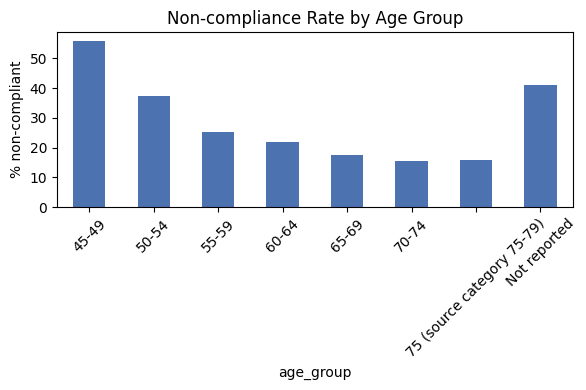

age_group
45-49                         55.9
50-54                         37.4
55-59                         25.1
60-64                         21.9
65-69                         17.4
70-74                         15.3
75 (source category 75-79)    15.7
Not reported                  40.9
Name: crc_noncompliant, dtype: float64

In [33]:
# Backup: non-compliance by age group
age_summary = df.groupby("age_group")["crc_noncompliant"].mean().reindex(age_order) * 100

fig, ax = plt.subplots(figsize=(6,4))
age_summary.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_ylabel("% non-compliant")
ax.set_title("Non-compliance Rate by Age Group")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("../figures/fig5_noncompliance_by_age.png", dpi=150)
plt.show()
age_summary.round(1)


**What this shows:** non-compliance is highest in the youngest eligible group (45–49) and drops as age increases, before flattening out in the 60s–70s. Weaker and less monotonic than income or access, so kept as backup rather than a headline chart.

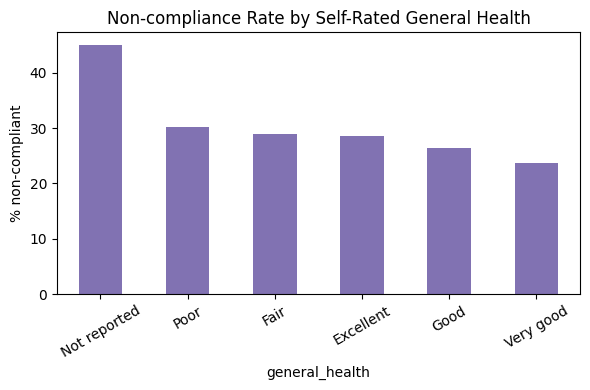

general_health
Not reported    45.0
Poor            30.3
Fair            28.9
Excellent       28.5
Good            26.5
Very good       23.7
Name: crc_noncompliant, dtype: float64

In [34]:
# Backup: non-compliance by general health status
genhealth_rates = df.groupby("general_health")["crc_noncompliant"].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(6,4))
genhealth_rates.plot(kind="bar", ax=ax, color="#8172B2")
ax.set_ylabel("% non-compliant")
ax.set_title("Non-compliance Rate by Self-Rated General Health")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.savefig("../figures/fig6_noncompliance_by_genhealth.png", dpi=150)
plt.show()
genhealth_rates.round(1)


**What this shows:** people who rate their own health as "poor" or "fair" tend to be somewhat more non-compliant than those in "excellent" or "very good" health — a modest gradient, consistent with the proposal's finding that "health status added little further" beyond access variables (Annex C ablation study).

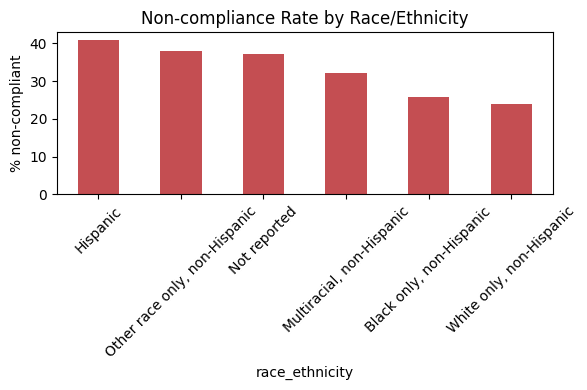

race_ethnicity
Hispanic                         40.9
Other race only, non-Hispanic    38.0
Not reported                     37.3
Multiracial, non-Hispanic        32.2
Black only, non-Hispanic         25.9
White only, non-Hispanic         24.0
Name: crc_noncompliant, dtype: float64

In [35]:
# Backup: non-compliance by race/ethnicity
race_rates = df.groupby("race_ethnicity")["crc_noncompliant"].mean().sort_values(ascending=False) * 100

fig, ax = plt.subplots(figsize=(6,4))
race_rates.plot(kind="bar", ax=ax, color="#C44E52")
ax.set_ylabel("% non-compliant")
ax.set_title("Non-compliance Rate by Race/Ethnicity")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.savefig("../figures/fig7_noncompliance_by_race.png", dpi=150)
plt.show()
race_rates.round(1)


**What this shows:** non-compliance varies noticeably across racial/ethnic groups, but this chart alone can't tell you why — the gap could reflect underlying income/insurance differences rather than race itself. This is exactly what the proposal's equity-check objective should investigate at the modelling stage, rather than being over-interpreted from this simple chart alone.

## Summary for the report

- **Sample:** 227,647 eligible respondents aged 45-75 — matches proposal exactly.
- **Outcome:** 26.5% non-compliant overall (19.3% never screened, 7.2% overdue) — matches proposal exactly.
- **Never-screened vs overdue:** these behave very differently across insurance and age — supporting
  a two-track outreach strategy rather than one generic non-compliance flag.
- **Income gradient:** every bracket reproduces the proposal's Annex C table exactly.
- **Access gap:** insurance and "no personal doctor" figures match exactly; "has personal doctor" is
  ~2 points lower in the final data than in the proposal's preliminary check — flagged for the team.
- **Recommended report charts:** recoding table, cohort flow, outcome distribution, never-screened-vs-overdue
  comparison, Table 1, income, and access — covering every Section 6.3 requirement plus the professor's
  feedback, without repetition. Age/race/health-status charts are kept as backup only.
